# IBM HR Analytics Employee Attrition Project
# Part 6 — Clustering and Classification Tie-In

## Business Objective

The objective of this stage is to connect employee segmentation results from clustering analysis with predictive attrition modelling results from classification analysis.

This allows the organisation to understand:
- which employee groups are most likely to leave,
- why these groups may be vulnerable,
- and what HR interventions should be prioritised.

Rather than viewing employees individually, this analysis introduces workforce personas that improve strategic decision-making.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)

In [3]:
# Load clustered dataset
df = pd.read_csv("../data/processed/hr_attrition_clustered.csv")

# Preview dataset
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure,Cluster,ClusterName
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,2,Moderately Stable Mid-Career Employees
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308,3,Compensation-Sensitive Retention Risk Employees
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.5

## Dataset Inspection

This dataset contains:
- engineered features,
- employee clusters,
- cluster personas,
- and attrition labels.

These variables allow clustering and classification findings to be connected together.

In [4]:
# Inspect cluster-related columns
df[["Cluster", "ClusterName", "Attrition"]].head()

,Cluster,ClusterName,Attrition
0,2,Moderately Stable Mid-Career Employees,1
1,4,Stable Long-Tenure Employees,0
2,3,Compensation-Sensitive Retention Risk Employees,1
3,4,Stable Long-Tenure Employees,0
4,3,Compensation-Sensitive Retention Risk Employees,0


## Cluster Attrition Analysis

This section evaluates attrition rates within each employee cluster.

The goal is to identify:
- which employee personas have the highest attrition risk,
- which groups appear stable,
- and how workforce segmentation relates to employee turnover.

In [5]:
# Calculate attrition metrics by cluster
cluster_attrition = df.groupby(
    ["Cluster", "ClusterName"]
)["Attrition"].agg(
    total_employees="count",
    attrition_count="sum",
    attrition_rate="mean"
).reset_index()

# Convert to percentage
cluster_attrition["attrition_rate"] = (
    cluster_attrition["attrition_rate"] * 100
).round(2)

# Workforce percentage
cluster_attrition["workforce_percentage"] = (
    cluster_attrition["total_employees"] / len(df) * 100
).round(2)

cluster_attrition

,Cluster,ClusterName,total_employees,attrition_count,attrition_rate,workforce_percentage
0,0,Early-Career Flight Risk Employees,83,33,39.76,5.65
1,1,Stable Experienced Core Employees,262,18,6.87,17.82
2,2,Moderately Stable Mid-Career Employees,305,53,17.38,20.75
3,3,Compensation-Sensitive Retention Risk Employees,497,100,20.12,33.81
4,4,Stable Long-Tenure Employees,323,33,10.22,21.97


## Cluster Attrition Findings

The cluster analysis revealed clear differences in attrition risk across employee personas.

Key findings include:

- The **Early-Career Flight Risk Employees** cluster recorded the highest attrition rate at approximately 39.8%, making it the most vulnerable employee segment in the organisation.
- The **Compensation-Sensitive Retention Risk Employees** cluster also showed elevated attrition risk at around 20.1%.
- The **Moderately Stable Mid-Career Employees** cluster demonstrated moderate attrition levels at 17.4%.
- The most stable groups were:
  - **Stable Experienced Core Employees** with an attrition rate of only 6.9%, and
  - **Stable Long-Tenure Employees** with an attrition rate of approximately 10.2%.

The findings suggest that employee turnover risk is not evenly distributed across the workforce. Instead, certain employee personas are significantly more vulnerable than others.

This demonstrates the value of workforce segmentation because it allows HR teams to focus retention strategies on the most at-risk employee groups rather than applying generic interventions organisation-wide.

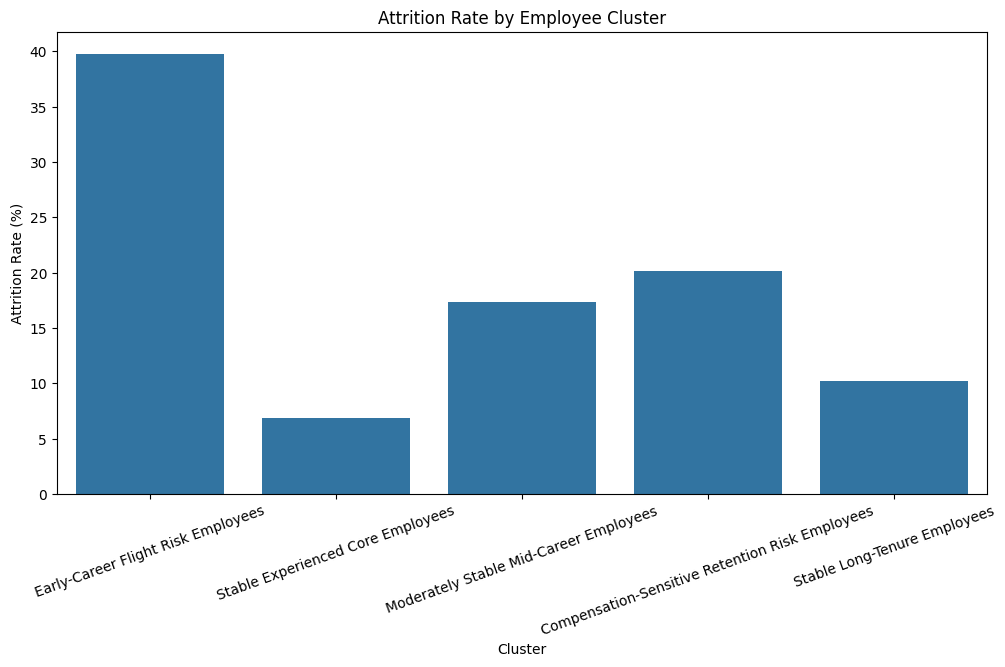

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_attrition,
    x="ClusterName",
    y="attrition_rate"
)

plt.xticks(rotation=20)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Cluster")
plt.title("Attrition Rate by Employee Cluster")

plt.show()

## Attrition Rate Visualisation Findings

The attrition rate visualisation clearly highlights major differences between employee clusters.

The **Early-Career Flight Risk Employees** cluster stands out as the highest-risk group by a substantial margin. This suggests that younger or less-established employees may be more likely to leave due to:
- career uncertainty,
- compensation dissatisfaction,
- limited organisational attachment,
- or external job opportunities.

The **Compensation-Sensitive Retention Risk Employees** cluster also exhibits noticeably elevated attrition levels, suggesting that compensation-related concerns may play an important role in employee turnover.

In contrast, the **Stable Experienced Core Employees** cluster demonstrates the lowest attrition rate, indicating stronger organisational attachment and higher workforce stability.

The visualisation confirms that attrition risk varies significantly between employee personas, reinforcing the importance of targeted HR intervention strategies.

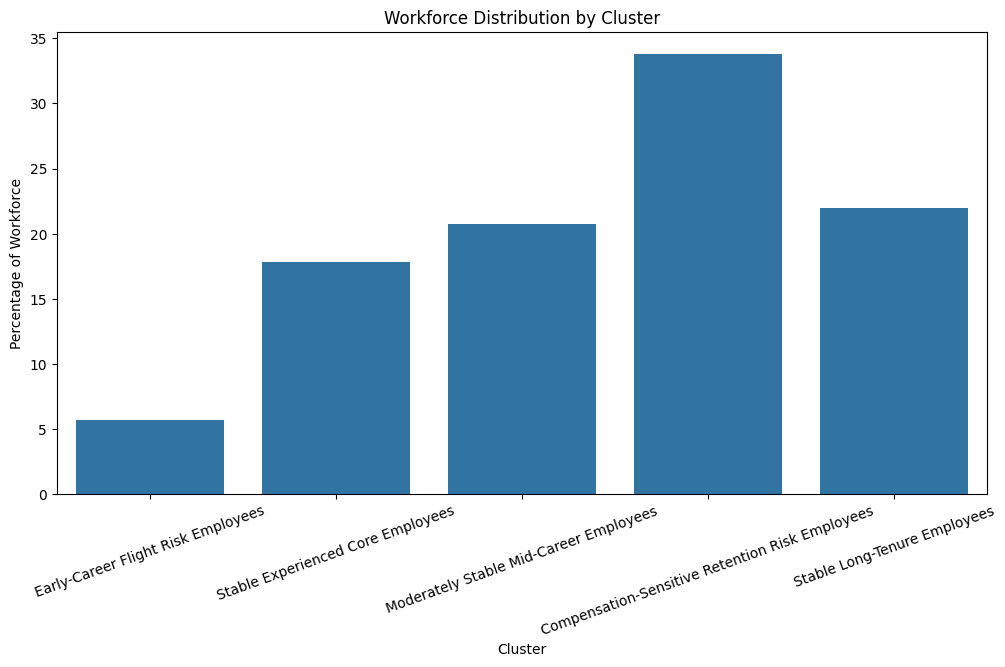

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_attrition,
    x="ClusterName",
    y="workforce_percentage"
)

plt.xticks(rotation=20)
plt.ylabel("Percentage of Workforce")
plt.xlabel("Cluster")
plt.title("Workforce Distribution by Cluster")

plt.show()

## Workforce Distribution Findings

The workforce distribution analysis provides important strategic context when interpreting attrition risk.

Key findings include:

- The **Compensation-Sensitive Retention Risk Employees** cluster represents the largest workforce segment at approximately 33.8% of employees.
- Although its attrition rate is not the highest overall, the large workforce size means this cluster contributes significantly to total employee turnover.
- The **Moderately Stable Mid-Career Employees** cluster and **Stable Long-Tenure Employees** cluster also represent large portions of the workforce.
- The **Early-Career Flight Risk Employees** cluster represents only 5.7% of employees, but its extremely high attrition rate makes it strategically important despite its smaller size.

These findings demonstrate that HR risk should not be evaluated using attrition rate alone.

A cluster with:
- moderate attrition but very large workforce size
may create greater organisational disruption than:
- a smaller cluster with extreme attrition risk.

This highlights the importance of balancing:
- attrition severity,
- workforce exposure,
- and operational impact
when prioritising retention strategies.

## Connecting Clustering and Classification

The clustering analysis identified employee personas, while the classification models identified the strongest predictors of attrition.

This tie-in allows the project to answer both:
- "Who is likely to leave?"
and:
- "What type of employee is likely to leave?"

The integration of clustering and classification improves:
- interpretability,
- strategic HR planning,
- and intervention targeting.

In [9]:
# Key features for comparison
key_features = [
    "MonthlyIncome",
    "OverTime",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance"
]

# Cluster-level feature means
cluster_feature_summary = df.groupby(
    "ClusterName"
)[key_features].mean().round(2)

cluster_feature_summary

,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance
ClusterName,,,,,
Compensation-Sensitive Retention Risk Employees,-0.62,0.01,-0.68,-0.01,-0.04
Early-Career Flight Risk Employees,-0.82,0.01,-0.67,0.01,0.18
Moderately Stable Mid-Career Employees,0.02,0.01,-0.06,0.06,0.07
Stable Experienced Core Employees,1.81,0.02,1.09,-0.04,0.01
Stable Long-Tenure Employees,-0.32,-0.05,0.38,-0.01,-0.06


## Connecting Clustering and Classification

The clustering analysis identified employee personas, while the classification models identified the strongest predictors of attrition.

The relationship between both analyses is highly consistent.

The classification models identified important attrition predictors such as:
- overtime,
- income,
- tenure,
- job satisfaction,
- work-life balance,
- and total working years.

These same characteristics also appeared within the high-risk employee clusters identified through K-Means clustering.

For example:
- the **Early-Career Flight Risk Employees** cluster showed lower income levels and shorter tenure,
- while the **Compensation-Sensitive Retention Risk Employees** cluster demonstrated compensation-related vulnerability.

This demonstrates that the clustering analysis supports and strengthens the classification findings.

The integration of both approaches improves:
- interpretability,
- strategic workforce understanding,
- and intervention targeting.

Classification predicts:
- which employees are likely to leave,

while clustering explains:
- what type of employees are most vulnerable
and:
- why they may be at risk.

Together, they create a far more actionable workforce intelligence system for HR decision-making.

## Feature Relationship Findings

The cluster-level feature analysis revealed several important relationships between employee characteristics and attrition risk.

### Income Patterns
High-risk clusters generally demonstrated lower income levels:
- the **Early-Career Flight Risk Employees** cluster had the lowest income profile,
- while the **Stable Experienced Core Employees** cluster had the highest income levels.

This supports the classification findings where income-related features were identified as important predictors of attrition.

---

### Tenure Patterns
Employees with:
- lower years at company,
- and lower total working years

showed higher attrition risk.

The **Early-Career Flight Risk Employees** cluster exhibited the shortest tenure levels and the highest attrition rate.

In contrast:
- the **Stable Experienced Core Employees** cluster showed significantly higher tenure and much lower attrition.

This aligns strongly with the classification feature importance results where tenure-related variables consistently appeared among the strongest predictors.

---

### Satisfaction and Work-Life Balance
Although satisfaction variables showed smaller numerical differences across clusters, lower satisfaction and weaker work-life balance were still associated with elevated attrition risk.

This suggests that dissatisfaction may interact with other factors such as:
- compensation,
- career progression,
- and workload.

---

### Overtime and Risk Exposure
Overtime-related variables also contributed to attrition risk patterns identified in the classification models.

This reinforces the business interpretation that workload pressure and burnout may influence employee turnover behaviour.

Overall, the clustering analysis validates the classification results and provides additional context regarding how these features combine to form distinct workforce personas.

## Strategic HR Recommendations

The tie-in analysis allows HR teams to move beyond general retention strategies and adopt more targeted workforce interventions.

### Early-Career Flight Risk Employees
Risk Level:
- Very High

Recommended Interventions:
- strengthen onboarding and mentorship programmes,
- improve early-career progression pathways,
- provide clearer promotion opportunities,
- increase engagement and career development support,
- review compensation competitiveness for junior employees.

This cluster requires urgent attention because it demonstrates the highest attrition rate.

---

### Compensation-Sensitive Retention Risk Employees
Risk Level:
- High

Recommended Interventions:
- conduct salary benchmarking reviews,
- improve compensation transparency,
- strengthen performance reward structures,
- provide clearer long-term career growth opportunities.

Because this cluster represents the largest workforce segment, improving retention here may significantly reduce overall turnover.

---

### Moderately Stable Mid-Career Employees
Risk Level:
- Medium

Recommended Interventions:
- maintain employee engagement programmes,
- provide leadership development opportunities,
- strengthen work-life balance support,
- monitor workload and burnout indicators.

This group appears relatively stable but still contributes meaningfully to organisational attrition.

---

### Stable Experienced Core Employees
Risk Level:
- Low

Recommended Interventions:
- maintain current retention practices,
- strengthen succession planning,
- encourage knowledge sharing and mentoring.

These employees appear highly stable and valuable to organisational continuity.

---

### Stable Long-Tenure Employees
Risk Level:
- Low to Moderate

Recommended Interventions:
- continue long-term engagement initiatives,
- recognise employee loyalty,
- support flexible work and wellbeing policies.

This cluster demonstrates strong organisational attachment and stability.

### Cluster: Early-Career Flight Risk Employees

Risk Level:
- Very High

Key Characteristics:
- Lowest income levels
- Lower organisational tenure
- Early-career employee profile
- Highest attrition rate in the organisation

Likely Attrition Drivers:
- Limited career growth opportunities
- Compensation dissatisfaction
- Weak organisational attachment
- External job market opportunities

Recommended HR Actions:
- Introduce mentorship programmes
- Improve early-career development pathways
- Conduct compensation reviews
- Increase manager support and engagement
- Provide clearer promotion visibility

---

### Cluster: Compensation-Sensitive Retention Risk Employees

Risk Level:
- High

Key Characteristics:
- Large workforce segment
- Moderate-to-high attrition levels
- Compensation-related vulnerability

Likely Attrition Drivers:
- Perceived compensation inequality
- Limited financial progression
- Career stagnation concerns

Recommended HR Actions:
- Review compensation competitiveness
- Improve reward and recognition systems
- Strengthen internal mobility opportunities
- Increase retention-focused performance reviews

## Final Tie-In Conclusion

This stage demonstrated that clustering and classification provide complementary business value within employee attrition analytics.

The classification models successfully identified:
- which employees are likely to leave,

while the clustering analysis explained:
- the workforce personas behind those predictions.

The integration of both approaches revealed that attrition risk is concentrated within specific employee groups rather than being evenly distributed across the organisation.

Key high-risk personas included:
- Early-Career Flight Risk Employees,
- and Compensation-Sensitive Retention Risk Employees.

These groups exhibited characteristics such as:
- lower income,
- shorter tenure,
- weaker organisational attachment,
- and elevated turnover behaviour.

The combined analytical framework provides several important business advantages:
- improved interpretability,
- targeted HR intervention planning,
- proactive workforce risk management,
- and stronger strategic decision-making.

Rather than applying generic retention strategies across all employees, the organisation can now prioritise interventions based on:
- employee persona,
- risk level,
- and workforce impact.

This transforms the project from a standalone predictive modelling exercise into a practical workforce intelligence solution capable of supporting long-term employee retention strategy.

In [19]:
# Load the original clean dataset with unscaled values
df_original = pd.read_csv("../data/processed/hr_attrition_clean_day1.csv")

# Add cluster labels and cluster names from the clustered dataset
df_original["Cluster"] = df["Cluster"].values
df_original["ClusterName"] = df["ClusterName"].values

# Convert Attrition to numeric if needed
df_original["AttritionNumeric"] = df_original["Attrition"].map({
    "Yes": 1,
    "No": 0
}) if df_original["Attrition"].dtype == "object" else df_original["Attrition"]

# Key business features for comparison using original values
key_features = [
    "MonthlyIncome",
    "OverTime",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance",
    "AttritionNumeric"
]

# Convert OverTime to numeric for averaging if it is still Yes/No
df_original["OverTimeNumeric"] = df_original["OverTime"].map({
    "Yes": 1,
    "No": 0
}) if df_original["OverTime"].dtype == "object" else df_original["OverTime"]

# Replace OverTime with OverTimeNumeric in summary
business_features = [
    "MonthlyIncome",
    "OverTimeNumeric",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance",
    "AttritionNumeric"
]

# Cluster-level feature means using real, unscaled values
cluster_feature_summary = (
    df_original
    .groupby("ClusterName")[business_features]
    .mean()
    .round(2)
)

# Rename columns for clearer business interpretation
cluster_feature_summary = cluster_feature_summary.rename(columns={
    "MonthlyIncome": "Average Monthly Income",
    "OverTimeNumeric": "Overtime Rate",
    "YearsAtCompany": "Average Years at Company",
    "JobSatisfaction": "Average Job Satisfaction",
    "WorkLifeBalance": "Average Work-Life Balance",
    "AttritionNumeric": "Attrition Rate"
})

# Convert rate columns to percentages
cluster_feature_summary["Overtime Rate (%)"] = (
    cluster_feature_summary["Overtime Rate"] * 100
).round(2)

cluster_feature_summary["Attrition Rate (%)"] = (
    cluster_feature_summary["Attrition Rate"] * 100
).round(2)

# Drop raw rate columns after percentage conversion
cluster_feature_summary = cluster_feature_summary.drop(
    columns=["Overtime Rate", "Attrition Rate"]
)

cluster_feature_summary

,Average Monthly Income,Average Years at Company,Average Job Satisfaction,Average Work-Life Balance,Overtime Rate (%),Attrition Rate (%)
ClusterName,,,,,,
Compensation-Sensitive Retention Risk Employees,3588.39,2.86,2.72,2.73,29.0,20.0
Early-Career Flight Risk Employees,2626.00,2.92,2.73,2.89,29.0,40.0
Moderately Stable Mid-Career Employees,6593.75,6.67,2.79,2.81,29.0,17.0
Stable Experienced Core Employees,15027.97,13.67,2.69,2.77,29.0,7.0
Stable Long-Tenure Employees,4982.97,9.36,2.72,2.72,26.0,10.0


### Updated Feature Relationship Findings

Using the original unscaled values gives a clearer business interpretation of each employee cluster.

The **Early-Career Flight Risk Employees** cluster has the highest attrition rate at 40.0%. This group also has the lowest average monthly income (£2,626) and relatively short average tenure of 2.92 years. This suggests that lower compensation and early-stage organisational attachment may be key reasons why this group is more likely to leave.

The **Compensation-Sensitive Retention Risk Employees** cluster has an attrition rate of 20.0% and an average monthly income of £3,588.89. Although this group is not as high-risk as the early-career group, its lower income and short average tenure of 2.86 years suggest potential vulnerability around compensation and career progression.

The **Moderately Stable Mid-Career Employees** cluster has a moderate attrition rate of 17.0%, with an average monthly income of £6,593.75 and average tenure of 6.67 years. This group appears more established but may still require engagement and career development support.

The **Stable Experienced Core Employees** cluster has the lowest attrition rate at 7.0%. This group has the highest average monthly income (£15,027.97) and the longest average tenure of 13.67 years, suggesting stronger organisational attachment and financial stability.

The **Stable Long-Tenure Employees** cluster has a relatively low attrition rate of 10.0%, with average tenure of 9.36 years and average monthly income of £4,982.97. This suggests that tenure may provide some stability even where income is not the highest.

Overall, the unscaled values confirm that attrition risk is closely linked to compensation, tenure, and career stage. This supports the classification findings, where income, total working years, age, overtime, and tenure-related variables were important predictors of attrition.